# Creating A Calibrated XGBoost Model


--- 
# Load Modules/Libraries

---

In [1]:
from importlib.metadata import version
from pathlib import Path
import shap

from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import brier_score_loss, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb


In [2]:
pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "pandas",
        "xgboost"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.4.4
pandas version: 3.0.2
xgboost version: 3.2.0


--- 
# Retreieving the Data

---

In [3]:
# Data File constants
file_name = "cleaned_data.csv"
data_file_path = Path("data") / file_name

df = pd.read_csv(data_file_path)

--- 
# Get Training, Testing, and Validation Test Sets

---

##### Perform stratified splitting
Stratified splitting is crucial for small (< 1000 observations), imbalanced datasets. It ensures the target distribution (and implicitly the rare feature distributions) remains the same in both sets.

Using `stratify=y` in the train_test_split function ensures that your model evaluation is based on a representative sample of your data.


##### Encoding and Scaling
After splitting, encode categorical variables and scale continuous ones to prevent data leakage. In machine learning, if you encode or scale your entire dataset before splitting it into training and testing sets, the "testing" information "leaks" into the "training" process.

In [4]:
X = df.drop('target', axis=1)
y = df['target']

# 1. First Split: Separate out the Test set (20% of total)
# This leaves 80% for Train + Validation
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 2. Second Split: Split the remaining 80% into Train and Validation
# To get a 60/20/20 split, we take 25% of the 80% (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_train_val
)


#### Encoding the Key Categorical Features


| Feature | Type | Action Required |
| :--- | :--- | :--- |
| **cp** | Categorical (Nominal) | Dummy/One-Hot Encoding |
| **restecg** | Categorical (Nominal) | Dummy/One-Hot Encoding |
| **slope** | Categorical (Ordinal) | Dummy/One-Hot Encoding |
| **thal** | Categorical (Nominal) | Dummy/One-Hot Encoding |
| **ca** | Categorical (Discrete) | Dummy/One-Hot Encoding (Commonly) |
| **sex, fbs, exang** | Binary | None (Keep as 0/1) |


##### The specific features that require dummy variables (or one-hot encoding) are:
* **cp** (Chest Pain Type): Usually has 4 levels (0–3) representing typical angina, atypical angina, non-anginal pain, and asymptomatic.

* **restecg** (Resting Electrocardiographic Results): Typically has 3 levels (0, 1, 2) indicating normal, ST-T wave abnormality, or left ventricular hypertrophy.

* **slope** (The Slope of the Peak Exercise ST Segment): Usually has 3 levels (0, 1, 2) for upsloping, flat, and downsloping.

* **thal** (Thalassemia): Features 3 levels (often coded as 3, 6, 7 or 1, 2, 3) representing normal, fixed defect, and reversible defect.

* **ca** (Number of Major Vessels): While technically a count (0-4), it is often treated as a categorical variable in this specific classification task to improve model performance.

In [5]:
# --- PREVENTING LEAKAGE DURING ENCODING ---

# 3. Specify Categorical and Numerical Features
# We use 'columns' to specify categorical features. 
# 'drop_first=True' avoids the dummy variable trap.
categorical_cols = ["ca", "cp", "exang", "fbs", "restecg", "sex", "slope", "thal"]
numerical_cols = ["age", "chol", "oldpeak", "thalach", "trestbps"]

### Preprocessing and Creating a Pipeline

In [6]:
# Perform the Preprocessing (Scaling and Encodings)
# ColumnTransformer handles OneHotEncoder for categorical data and StandardScaler for numerical data

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ])

# Creat base XGBoost Classifier model which will be calibrated later
base_xgb = xgb.XGBClassifier(eval_metric="logloss", random_state=42)

pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("clf", base_xgb)])

---

### Perform the GridSearch with Nested Parameters
GridSearchCV tunes nested XGBoost hyperparameters within the Pipeline.

When you run `grid_search.fit(X_train, y_train)`, scikit-learn does two things:

* Search: It tests every combination of parameters in your `param_grid` using cross-validation to find which one performs best.

* Refit: Once the best parameters are found, it automatically re-trains the pipeline on the entire training set (`X_train`) using those specific settings.


#### Remember with Scaling Feature Values - make sure to prevent leakage
When you use a `StandardScaler`, it calculates the mean and standard deviation of the data to shift everything to a center of 0.

* **The Leak**: If you scale the whole dataset first, the scaler uses the values from the test set to calculate that mean.

* **The Consequence**: Your training data now "knows" the average value of the test data. The model is no longer being tested on truly "unseen" data because the test set's distribution influenced the training set's values.

* **The Fix**: Always fit the scaler on the Train set only, then transform both the Train and Test sets using those training parameters.

In [7]:
# Hyperparameter tuning using Training Data
param_grid = {
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.01, 0.1],
    "clf__n_estimators": [50, 100]
}

#n_jobs = -1 says use all available processors
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="roc_auc", refit=True)

#  --- MAKE SURE TO PREVENT LEAKAGE DURING SCALING  using only the Training data---
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__learning_rate': [0.01, 0.1], 'clf__max_depth': [3, 5], 'clf__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

# Initial Evaluation of the Uncalibrated Model

In [8]:
y_probs_non_cal = grid_search.predict_proba(X_test)[:, 1]
y_preds_non_cal = grid_search.predict(X_test)

### Calibrate the base XGBoost model : Perform probability calibration (using separate Validation data)
Calibration is used to ensure predicted probabilities match real-world frequencies.

Used strictly for Calibration. Since XGBoost's raw probabilities can be biased, `CalibratedClassifierCV` needs "fresh" data that wasn't used for the initial training to properly map scores to actual probabilities. Hence, the use of the validation training set.

Here, `cv="prefit"` because the pipeline was already trained during `GridSearch`

In [9]:
# grid_search.best_estimator_ is the final, optimized version of your entire machine learning Pipeline
# best_estimator_ is a Pipeline object containing: 
# * The Preprocessor: Your ColumnTransformer (StandardScaler + OneHotEncoder)
# * The Model: The XGBClassifier with the specific max_depth, learning_rate, and n_estimators that scored the highest.
best_pipeline = grid_search.best_estimator_

#The calibrated XGBoost model.
calibrated_model = CalibratedClassifierCV(
    estimator=best_pipeline, 
    method='sigmoid', 
    cv=None
)
calibrated_model.fit(X_val, y_val)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the 

### Final Evaluation Using the X_test Data

The `X_test` data was held out entirely until the very end to give an honest assessment of how the calibrated model performs on data it has never seen. 

In [10]:
y_probs = calibrated_model.predict_proba(X_test)[:, 1]
y_preds = calibrated_model.predict(X_test)

In [11]:
print(f"Test Non Calibrated Model ROC-AUC : {roc_auc_score(y_test, y_probs_non_cal):.4f}")
print(f"Test Brier Score on Non Calibrated Model: {brier_score_loss(y_test, y_probs_non_cal):.4f}")
print("\n Non Calibrated Final Test Classification Report:")
print(classification_report(y_test, y_preds_non_cal))
print("\n----------------------------\n")

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}")
print(f"Test Brier Score: {brier_score_loss(y_test, y_probs):.4f}")
print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_preds))

Test Non Calibrated Model ROC-AUC : 0.8929
Test Brier Score on Non Calibrated Model: 0.1273

 Non Calibrated Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.83      0.91      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61


----------------------------

Best Parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Test ROC-AUC: 0.8831
Test Brier Score: 0.1596

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72        28
           1       0.75      0.82      0.78        33

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61


---
# Analysis of the Results

---

### Looking at the Calibrated and Non Calibrated Model Scores


##### F1 Scores
| Model | F1 Score Before Calibration| F1 Score After Calibration|
| :--- | :--- | :--- |
| **XGBoost** | 0.85 | 0.75  |

##### ROC-AUC
| Model | ROC-AUC Score Before | ROC-AUC Score After Calibration|
| :--- | :--- | :--- |
| **XGBoost** | 0.8929 | 0.8831 |


##### Brier Scores
| Model | Brier Score Before | Brier Score After Calibration|
| :--- | :--- | :--- |
| **XGBoost** | 0.1273 | 0.1596 |


---
#### Commentary
The results look worse after calibration which seems a bit counterintuitive to what was expected: the model should have improved with calibration. Looking at the results, the "Best Parameters" found during the tuning phase actually yielded a lower ROC-AUC (0.8831) than the original non-calibrated model (0.8929).

Here are some reasons why the results appear worse:

1.  **The Hearts.CSV Dataset is Too Small (The "Data Hungry" Problem)**
The heart.csv dataset is tiny (~ 60 samples in your test set). Calibration methods—like Isotonic Regression or Platt Scaling—are essentially a second model trained on top of the first.
Calibrating using the same small training set, you likely overfit the calibration layer.
It would have been worse if I split the data further to create a fourth "calibration set," 
Essentially, I left the base calibrated XGBoost model with too little data to learn the actual patterns of heart disease.

2. **XGBoost is Already "Well-Behaved"**
XGBoost is naturally well-calibrated because it uses boosted trees to minimize log-loss. In small datasets, the default settings often provide probabilities that are "good enough." **Forcing a calibration curve onto such a small sample size usually adds noise rather than refinement.**

3. **Brier Score vs. Classification Accuracy**
The Brier Score (which rose from 0.1273 to 0.1596) measures the "closeness" of probability to the truth. Because your ROC-AUC also dropped, it means the model's ability to rank patients by risk decreased. If the model can't rank them correctly, no amount of calibration can fix the underlying probability errors.

---
### Summary of the “Why”
Before we get too excited, the truth is that **Calibration** didn't fail.  The tuning/modeling process likely led to a less predictive base model. In small datasets like heart.csv, a simple, uncalibrated XGBoost model often beats a complex, multi-stage calibrated pipeline because the latter is too complex for ~300 total rows of data.

This situation is a clear example of why you have to keep evaluating your results and why you shouldn’t blindly assume that just because you perform some supposed improvement technique that it does indeed improve the model.

----
----
----
### Understanding Which Features Were the most Important 

Feature importance helps us make XGBoost more than just a black box that is just outputting numbers. 

Feature importance helps to explain why the model made decisions. It provides a sanity check. If the model says "cholestrol" is irrelevant, then we know something is wrong with the model or the data. Feature importance can align the model's logic with real life medical reality. It provides the documentation needed to prove the model isn't being biased or using "garbage" data.

Feature importance can help with feature selection, feature importance help tell you which features to prune. This pruning is especially important when datasets have hundreds of features (columns).

Feature importance can also help out with identifying data leakage. If a feature has a 99% importance score, it’s often a red flag for leakage. For example, if your dataset accidentally included a column like "Patient_Prescribed_Heart_Medication," the model would use that to "cheat" and predict heart disease perfectly without actually learning the underlying health patterns.

In healthcare, a patient doesn't just want to know they have a high risk; they want to know why. Feature importance allows you to say: "Your risk is high primarily because of your thalach (max heart rate) and ca (number of major vessels)."

XGBoost gives you three ways to measure importance: Weight (how often a feature is used), Cover (how many samples it affects), and Gain (how much accuracy it adds). Gain is usually the most reliable for understanding what actually drives the prediction. The model tracks the metrics as it builds its trees. Each metric tells a different story about how your features contribute to the heart disease prediction.



In [12]:
# Finding the model name fromt he pipeline
print(grid_search.best_estimator_.named_steps.keys())


dict_keys(['preprocessor', 'clf'])


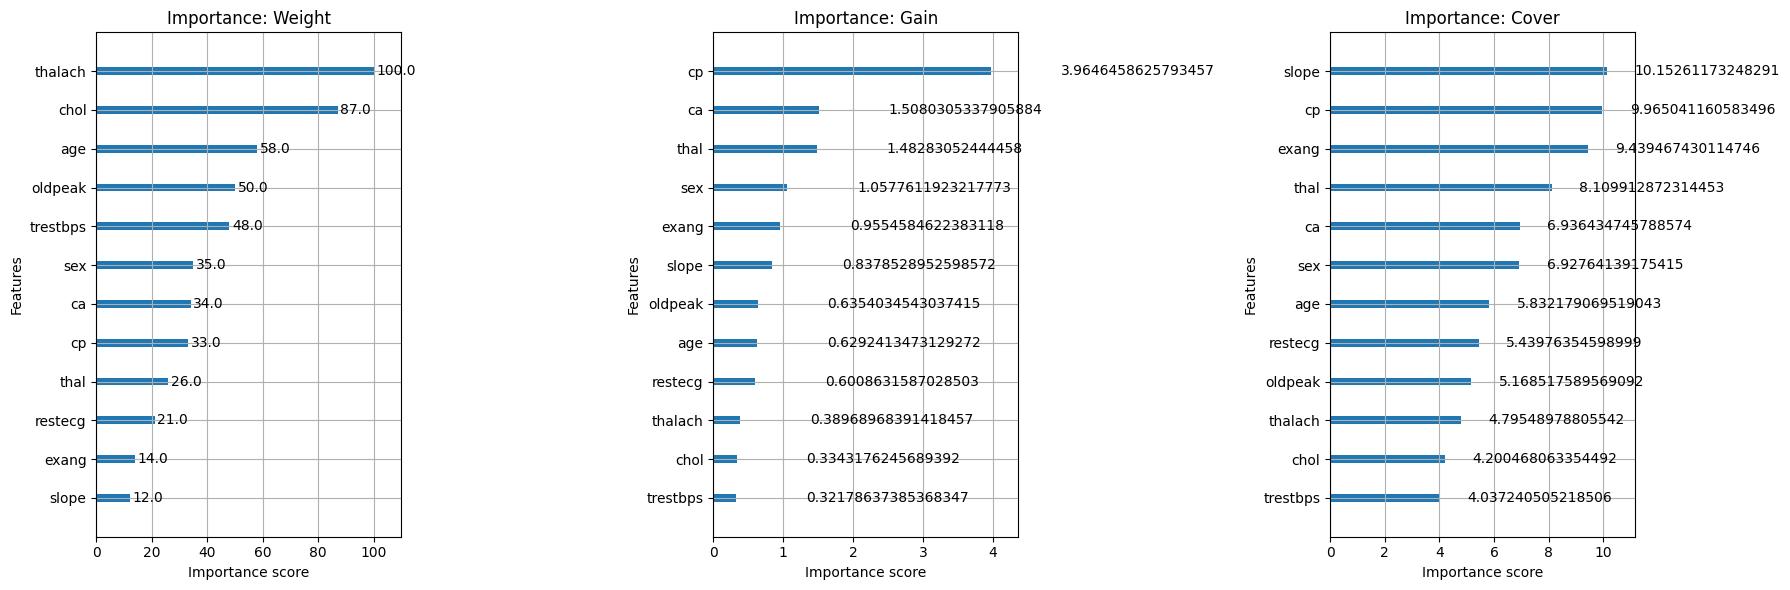

In [13]:
# Looking Plots of Cover, Gain, and Weight
# Using the uncalibrated, better, model

# Create a figure with 3 subplots for each importance type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Access the booster object 
# xgb.plot_importance expects a trained Booster
xgb_model = pipeline.named_steps["clf"]
xgb_model.fit(X_train, y_train)
booster =xgb_model.get_booster()

# Plot Weight
xgb.plot_importance(booster, importance_type='weight', ax=axes[0], title='Importance: Weight')

# Plot Gain
xgb.plot_importance(booster, importance_type='gain', ax=axes[1], title='Importance: Gain')

# Plot Cover
xgb.plot_importance(booster, importance_type='cover', ax=axes[2], title='Importance: Cover')

plt.tight_layout()
plt.show()


### Analysis of the Feature Importances

The heart disease model prioritizes different features depending on the metric used. Here is a summary of the key findings:

1. Top Predictive Features

* Most Influential (Gain): `cp` (Chest Pain Type) is by far the most important feature for increasing model accuracy. Its high gain suggests it is the primary indicator the model uses to differentiate between healthy and diseased states.

* Most Frequent (Weight): `thalach` (Maximum Heart Rate) is the feature used most often to split data across the trees. While it appears frequently, its lower "Gain" suggests it provides many small refinements rather than one massive predictive leap.

* High Impact (Cover): `slope` (Slope of the Peak Exercise ST Segment) has the highest "Cover," meaning it describes the largest number of samples across the dataset.

2. Key Discrepancies

* `thalach vs. cp`: While `thalach` is used most often (Weight), `cp` provides more predictive value (Gain). This often indicates that `thalach` is a useful "fine-tuner" for many specific cases, whereas `cp` is a strong general predictor.

* `chol (Cholesterol)`: This feature appears very high in frequency (Weight) but is near the bottom for Gain and Cover. This suggests that while the model checks cholesterol often, it doesn't significantly change the final prediction in most instances compared to other factors.


3. Medical Takeaway
The model relies heavily on clinical symptoms `(cp)` and stress test results (`slope`, `exang`, `ca`) to make its most accurate predictions. Traditional risk factors like `age` and `chol` are used frequently as secondary filters but carry less weight in the final determination of heart disease.


### Looking at Shaply Additive Explanations (SHAP) for Feature Importance 

Alternative to the big three above for explaining feature importance is Shaply Additive Explanations. SHAP tells you about the individual predictions. We use SHAP when we need to explain to a human why a specific decision was made.

#### Why SHAP might be better for feature :

* **Directional**: Unlike Gain, SHAP tells you if a feature pushed the prediction up or down.

* **Consistency**: Gain can sometimes be biased toward continuous features (like restecg) over binary ones (like cp). SHAP is mathematically "fair."

* **Local vs. Global**: You can see why one specific person had higher scores, or average all SHAP values to see the general trend.

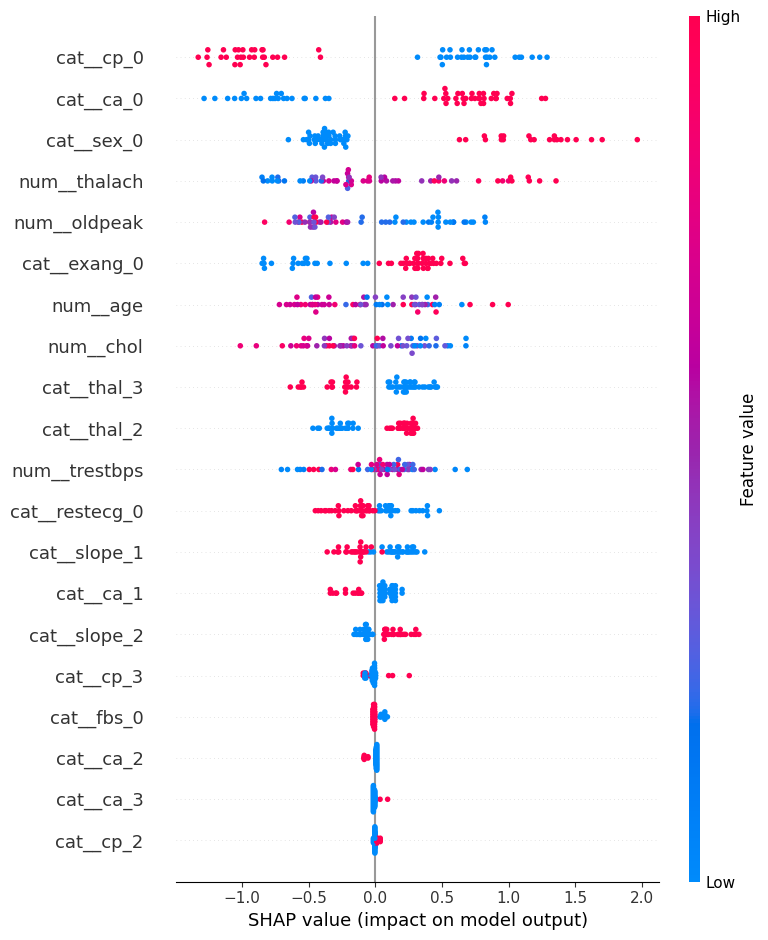

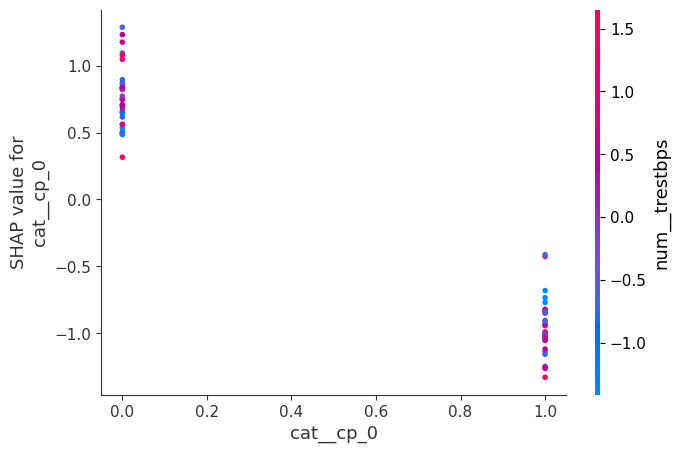

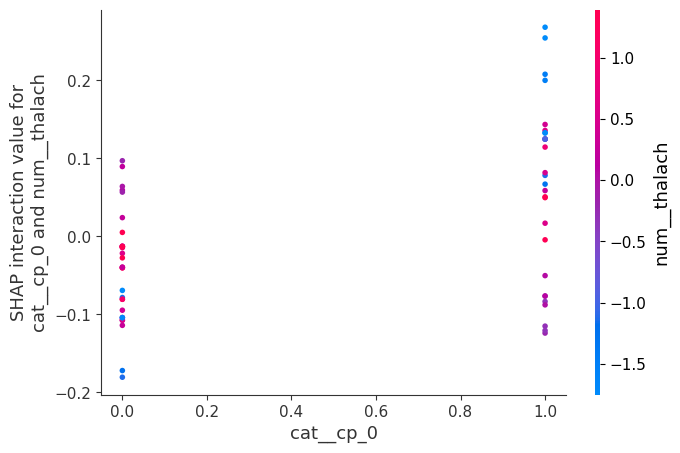

In [40]:
# 1. Extract the model and data from your pipeline/grid search
# Replace 'model' with your specific pipeline step name
#xgb_model = grid_search.best_estimator_.named_steps['model']
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

xgb_model = best_pipeline.named_steps["clf"]

# 1. Get the exact feature names generated by the pipeline
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Access steps from the FITTED version
X_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)


# Convert your transformed array into a DataFrame with those names
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)




# 2. Calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_transformed_df)
#shap_values = explainer.shap_values(X_transformed)

# 3. Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_transformed, plot_type="dot")

# 4. Dependence Plot (example for 'cp' - chest pain)
# This shows how the impact of 'cp' changes with its value
# Note: If 'cp' was one-hot encoded, it will now be 'cat__cp_1', 'cat__cp_2', etc.
# Check your feature_names list to see the exact string!
shap_values = explainer.shap_values(X_transformed)
shap.dependence_plot("cat__cp_0", shap_values, X_transformed_df)
#shap.dependence_plot("cp", shap_values, X_transformed)

# 5. Interaction Values (Note: This is computationally expensive)
interaction_values = explainer.shap_interaction_values(X_transformed)
# Plot interaction between two features (e.g., 'cp' and 'thalach')
#shap.dependence_plot(("cat__cp_0", "num__thalach"), interaction_values, X_transformed)
shap.dependence_plot(("cat__cp_0", "num__thalach"), interaction_values, X_transformed_df)


#### SHAP Beeswarm Plot Review
The first plot, the SHAP beeswarm plot, visualizes how your XGBoost model makes decisions. It ranks features by importance (top to bottom) and shows how the value of a feature (color) affects the prediction (horizontal axis).

The model relies heavily on `Chest Pain type`, `Number of Major Vessels`, and `Sex`. Traditional risk factors like Blood Pressure (trestbps) and Cholesterol are surprisingly low on the list, suggesting that in this specific dataset, clinical symptoms and physiological markers like heart rate are much stronger predictors.

##### Here is the interpretation for the heart disease model:

1. The Top Predictors
* `Chest Pain (cat__cp_0)`: This is the most influential feature. Since a Low feature value (blue) results in a high positive SHAP value, patients without this specific chest pain type are significantly more likely to be predicted as having heart disease.

* `Major Vessels (cat__ca_0`): This is the second most important. High values (red) push the prediction toward positive (heart disease), while Low values (blue) push it toward negative.

* `Sex (cat__sex_0)`: Being in category "0" for sex (likely female, depending on your encoding) shows a strong positive impact on the model's output.


##### Directional Trends (Numerical)
* `Maximum Heart Rate (num__thalach)`: Higher heart rates (red) generally correlate with a positive impact on the prediction (shifting points to the right).

* `ST Depression (num__oldpeak)`: There is a clear inverse relationship here. Lower values (blue) for oldpeak are associated with higher SHAP values (risk), while higher values (red) reduce the risk prediction.

* `Age and Cholesterol`: These show a "messier" distribution centered around zero, suggesting they have a moderate impact that varies significantly depending on other features (interactions).


##### Understanding the "Spread"
* `Outliers`: Note the points for cat__sex_0 stretching far to the right (past 2.0). This indicates that for some specific patients, their sex is an extremely strong indicator of heart disease according to the model.

* `Binary` Clusters: Features like cat__exang_0 (Exercise Induced Angina) show two distinct clusters. This is typical for One-Hot Encoded categorical variables—you are either a "0" or a "1," with very little middle ground in the impact.


### SHAP Dependence Plot Review

This SHAP Dependence Plot shows the relationship between Chest Pain type 0 `(cat__cp_0)` and the model's prediction, while highlighting how it interacts with Blood Pressure `(num_trestbps)`.

The model sees `cat__cp_0 = 0` as a major risk factor. That risk is amplified even further if the patient also has high blood pressure.


1. Main Effect: Chest Pain (`cat__cp_0`)

The x-axis represents the binary value of the feature (0 or 1).

* When `cat__cp_0 is 0`: The SHAP values are positive (roughly +0.5 to +1.3). This means that not having this specific chest pain type significantly increases the predicted probability of heart disease.

* When `cat__cp_0 is 1`: The SHAP values are negative (roughly -0.5 to -1.3). This means having this chest pain type decreases the risk prediction.

2. Interaction Effect: Blood Pressure (`num_trestbps`)

The colors represent the scaled value of Resting Blood Pressure.

* `High Blood Pressure (Red)`: At cat__cp_0 = 0, the red dots are clustered at the higher end of the SHAP scale (near +1.2). This suggests that for patients without this chest pain type, having high blood pressure adds an extra "risk boost."

* `Low Blood Pressure (Blue)`: At cat__cp_0 = 1, the blue dots are slightly higher than the red ones. This suggests that low blood pressure might slightly "buffer" the protective effect of having this chest pain type.

### SHAP Interaction Plot Review

This SHAP Interaction Plot specifically isolates the synergy between Chest Pain (`cat__cp_0`) and Max Heart Rate (`num__thalach`). Unlike the previous dependence plot, this one removes the "main effect" of each feature to show only how they amplify or cancel each other out.

The model has learned a "conditional rule": the impact of Max Heart Rate on your risk score changes direction depending on which Chest Pain category you fall into. A low heart rate is "worse" for the risk score if you have `cat__cp_0`, but "better" if you don't.

1. The Interaction Logic

* The Y-axis (`Interaction Value`): Values above 
 indicate that the combination of these two features increases the prediction more than the sum of their individual parts. Values below 
 mean the combination lowers the prediction.

* The X-axis (`cat__cp_0`): Split into 
 (does not have this chest pain type) and 
 (has this chest pain type).

2. High Heart Rate Influence (Red Dots)

* At `cat__cp_0 = 1`: The red dots (high heart rate) are clustered near or slightly above 
. This suggests that for people with this chest pain type, a high heart rate has a neutral to slightly positive interaction effect.

* At `cat__cp_0 = 0`: The red dots are scattered across the middle.

3. Low Heart Rate Influence (Blue Dots)
* The Split Effect: This is the most interesting part of the graph.

    * For patients with the chest pain (1.0), low heart rate (blue) results in a high positive interaction (top right). The model finds the combination of this chest pain AND low heart rate particularly noteworthy for heart disease risk.

    * For patients without the chest pain (0.0), low heart rate (blue) results in a negative interaction (bottom left). This combination actively pushes the model's prediction downward.



---
---
---
# How to Use the Calibration Model or The Uncalibrated Model in this Case in Practice

Here we show how to use the best model, where the real value comes in, especially for a medical dataset like hearts.csv.

This section provides an example using best model obtained from earlier

### Save the Model

So we don't have to re-train and re-calibrate every time. 

Use `joblib` to save the entire model pipeline to ensure your model is applied to new data exactly as it was during training, the best practice is to save the entire Scikit-learn Pipeline. `joblib` is preferred for Scikit-learn workflows because it captures the entire data transformation logic. It bundles your StandardScaler, OneHotEncoder, and XGBClassifier into a single object, preventing "data leakage" and ensuring consistency.

Using the entire pipeline guarantees that your dummy data is scaled using the exact same mean and standard deviation as your training set.


**Note** because, I used `One-Hot Encoding`'s `handle_unknown="ignore"` in the encoder, the model won't crash if the dummy data contains a category value it didn't see during training.



In [ ]:
# Need to ensure that we fit the model in the pipeline before saving
pipeline.fit(X_train, y_train)

# Save the calibrated SVC or RF model
joblib.dump(pipeline, "heart_disease_pipeline.pkl")
print("Pipeline saved successfully")


### Predict Probabilities (Not Just Labels)

In a heart disease context, a simple "0" or "1" (No Heart Disease/ Heart Disease) isn't enough. You want the model probability. Use `.predict_proba()` to get the percentage risk.

In [ ]:
# Load the pipeline
loaded_model = joblib.load("heart_disease_pipeline.pkl")

# Define dummy data (Raw values, no prior processing needed)
dummy_patient = pd.DataFrame([{
    'age': 58, 'sex': 1, 'cp': 2, 'trestbps': 140, 'chol': 220,
    'fbs': 0, 'restecg': 1, 'thalach': 160, 'exang': 0,
    'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 3
}])


# Test the model
# The pipeline handles all scaling and encoding automatically
prediction = loaded_model.predict(dummy_patient)
probability = loaded_model.predict_proba(dummy_patient)[:, 1]

print(f"Prediction: {'Heart Disease' if prediction[0] == 1 else 'Healthy'}")
print(f"Risk Score (Probability): {probability[0]*1:.2f} Risk of heart disease.")

### Setting a "Clinical" Decision Threshold
In standard classification, the threshold is 0.5. But in heart disease, a False Negative (missing a sick patient) is much more dangerous than a False Positive (running an extra test on a healthy person).

**Without calibration, a "0.30" score might actually mean a 10% or 50% risk. With your calibrated model, you know 0.30 means approximately 30% frequency in the real world.**

Because your model is now calibrated, you can set a "Safety Threshold" with confidence:

* High Sensitivity (Safe): If risk > 0.30, refer for further testing.
* Standard: If risk > 0.50, diagnose as positive.
* High Specificity (Conservative): If risk > 0.80, proceed to immediate treatment.



#### Patient Risk Stratification
You can use the calibrated output to sort patients into "Risk Tiers" for a hospital dashboard:


| Risk Score | Category | Action |
| :--- | :--- | :--- |
| 0.0 - 0.2 | Low Risk | Routine check-up in 12 months. |
| 0.2 - 0.5 | Elevated | Monitor and suggest lifestyle changes. |
| 0.5 - 0.8 | High Risk | Schedule diagnostic imaging (ECG/Stress Test). |
| 0.8 - 1.0 | Critical | Urgent specialist consultation. |
